# Tutorial 3: Training DeepE2EROM Models

This tutorial demonstrates how to train the models created in Tutorial 2 using the datasets processed in Tutorial 1. We will use the `Trainer` module which handles the training loop, loss calculation, validation, and history tracking.

## Table of Contents
1. [Data Preparation](#data-prep)
2. [Model Creation](#model-creation)
3. [The Trainer Module](#trainer-module)
4. [Training Loop](#training-loop)
5. [Evaluation & Visualization](#evaluation)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import deepe2erom
from deepe2erom import DataConfig, DataPreprocessor, create_model, Trainer

print(f"DeepE2EROM version: {deepe2erom.__version__}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DeepE2EROM version: 0.1.0
Using device: cuda


## 1. Data Preparation <a name="data-prep"></a>

First, we generate synthetic data (1D Heat Equation) and process it, similar to Tutorial 1.

In [10]:
# --- Generate Synthetic Data (Same as Tutorial 1) ---
n_simulations = 100
n_timesteps = 100
state_dim = 64
control_dim = 2

states = np.zeros((n_simulations, n_timesteps, state_dim))
controls = np.random.randn(n_simulations, n_timesteps, control_dim)

# Heat equation parameters
alpha, dt, dx = 1.0, 0.1, 1.0
r = alpha * dt / (dx**2)

for sim in range(n_simulations):
    # Initial condition
    x_grid = np.linspace(0, 10, state_dim)
    states[sim, 0] = 20.0 + 80.0 * np.exp(-0.5 * (x_grid - np.random.uniform(2, 8))**2)
    
    for t in range(1, n_timesteps):
        u = states[sim, t-1]
        diffusion = r * (u[:-2] - 2*u[1:-1] + u[2:])
        
        # Control effect
        control_effect = np.zeros(state_dim - 2)
        control_effect[10] += 0.5 * controls[sim, t, 0] 
        control_effect[-10] += 0.5 * controls[sim, t, 1]
        
        states[sim, t, 1:-1] = u[1:-1] + diffusion + control_effect
        states[sim, t, 0] = states[sim, t, -1] = 20.0 # Boundary conditions

print(f"Generated data: States {states.shape}, Controls {controls.shape}")

Generated data: States (100, 100, 64), Controls (100, 100, 2)


In [45]:
data = np.load('./data/heat_equation_data.npz')
states = data['all_U_histories']
controls = data['all_F_histories']

In [46]:
# visualize one simulation
from deepe2erom import animate_1Dsimulation
animate_1Dsimulation(states[52], save_path="./images/1D_simulation.gif", title="1D Heat Diffusion Simulation")

Preprocess the simulation data for training using the `DataPreprocessor`:

In [47]:
# --- Process Data ---
lookback = 10
pred_horizon = 5
state_dim = states.shape[2]
control_dim = controls.shape[2]
config = DataConfig(
    # Data splitting
    train_split=0.2,
    val_split=0.1,
    test_split=0.7,

    # state and control dimensions
    state_dim=state_dim,
    control_dim=control_dim,
    
    # Sequence parameters
    lookback=lookback,              # Use lookback past time steps as input
    pred_horizon=pred_horizon,      # Predict pred_horizon future time steps
    stride=1,                       # No skipping between sequences
    
    # Scaling
    scale_states=False,
    scale_controls=True,
    scale_states_collectively=False,     # Scale all states together (one high-dimensional field)
    scale_controls_collectively=True,  # Scale controls together (one high-dimensional field)
    scaling_method="minmax",            # Scaling method: "minmax" or "standard"
    
    # Device
    device=device
)

processor = DataPreprocessor(config)
processed_data = processor.process_simulations(states, controls)

Scaling controls using:  minmax


After preprocessing, the processed sequences can be efficiently loaded into a PyTorch `DataLoader` for batch processing. The `DataLoader` handles:

- **Batching**: Groups individual sequences into batches for parallel processing
- **Shuffling**: Randomizes sample order (typically for training data)
- **Parallel Loading**: Utilizes multiple workers for faster data loading

In [48]:
# Create DataLoaders
batch_size = 256
train_loader = DataLoader(processed_data['datasets']['train'], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(processed_data['datasets']['val'], batch_size=batch_size)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 926
Val batches: 463


## 2. Model Creation <a name="model-creation"></a>

We create a Control-Affine model suitable for this data.

In [49]:
latent_dim = 6
control_latent_dim = 6

# Encoder/Decoder Architectures
encoder_arch = [
    {"type": "Linear", "params": {"in_features": state_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": latent_dim}},
]

decoder_arch = [
    {"type": "Linear", "params": {"in_features": latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": state_dim}},
]

# Encoder/Decoder Architectures for Control Autoencoder
encoder_arch_control = [
    {"type": "Linear", "params": {"in_features": control_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": control_latent_dim}},
    {"type": "Sigmoid"},
]

decoder_arch_control = [
    {"type": "Linear", "params": {"in_features": control_latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": control_dim}},
    {"type": "Sigmoid"},
]

# Dynamics Architectures
# Input to dynamics is: latent_dim * lookback + control_dim * (lookback - 1)
dyn_input_dim = latent_dim * config.lookback + control_latent_dim * (config.lookback - 1)

drift_arch = [
    {"type": "Linear", "params": {"in_features": dyn_input_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim}}
]

input_arch = [
    {"type": "Linear", "params": {"in_features": dyn_input_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim*control_latent_dim}}
]

model = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=config.lookback,
    pred_horizon=config.pred_horizon,
    latent_dim=latent_dim,
    control_latent_dim=control_latent_dim,
    dynamics_type="control_affine",
    drift_arch=drift_arch,
    input_arch=input_arch,
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    use_control_autoencoder=True,
    control_encoder_arch=encoder_arch_control,
    control_decoder_arch=decoder_arch_control,
    device=device
)

print("Model created successfully.")

model.count_parameters()

Model created successfully.
MODEL PARAMETER COUNT
encoder         |    8,806 total |    8,806 trainable
decoder         |    8,901 total |    8,901 trainable
dynamics        |   67,882 total |   67,882 trainable
control_encoder |    8,806 total |    8,806 trainable
control_decoder |    8,901 total |    8,901 trainable
------------------------------------------------------------
TOTAL           |  103,296 total |  103,296 trainable


{'encoder': {'total': 8806, 'trainable': 8806},
 'decoder': {'total': 8901, 'trainable': 8901},
 'dynamics': {'total': 67882, 'trainable': 67882},
 'control_encoder': {'total': 8806, 'trainable': 8806},
 'control_decoder': {'total': 8901, 'trainable': 8901},
 'total': {'total': 103296, 'trainable': 103296}}

## 3. The Trainer Module <a name="trainer-module"></a>

The `Trainer` class simplifies the training process. It manages the optimization of a composite loss function consisting of:

1.  **Reconstruction Loss** (`rec_loss`): MSE between original and reconstructed states.
2.  **Prediction Loss** (`pred_loss`): MSE between predicted future states and ground truth.
3.  **Latent Consistency Loss** (`latent_loss`): MSE between predicted latent states and encoded ground truth states.
4.  **Input Reconstruction Loss** (`input_rec_loss`): (Optional) If using a control autoencoder.

You can weight these components to guide training.

In [50]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    rec_weight=1.0,       # Weight for state reconstruction
    input_rec_weight=1.0, # Weight for control reconstruction
    pred_weight=0.1,      # Weight for future prediction
    latent_weight=1.0,    # Weight for latent space consistency
    learning_rate=1e-3,   # Learning rate
    restarts=2,           # Number of training restarts
    device=device
)

print("Trainer initialized.")

Trainer initialized.


## 4. Training Loop <a name="training-loop"></a>

The `train` method executes the training pipeline, which consists of two stages:

1.  **Autoencoder Pre-training**: Trains only the autoencoders for `ae_epochs` to establish a good latent space before learning dynamics.
2.  **Full Training**: Trains the entire end-to-end model for `epochs`.

The training loop has the following features:
 - **Restarts**: Can run the training multiple times (`restarts`) to find the best initialization.
 - **Early Stopping**: Monitors validation loss to stop if no improvement is seen for `patience_early_stopping` epochs.
 - **Learning Rate Schedulizer**: The learning rate is reduced by half if the validation loss did not improve for `patience_lr_scheduler` epochs.
 - **Saving**: Saves the best model and training history to `save_path`.

In [51]:
save_dir = "./tutorial_training_results"

best_loss = trainer.train(
    train_loader=train_loader,
    valid_data=val_loader,
    epochs=150,                          # Maximum epochs for full training
    ae_epochs=10,                        # Pre-train autoencoders for 10 epochs                     
    patience_early_stopping=20,          # Early stopping patience
    patience_lr_scheduler=10,            # LR scheduler patience
    save_path=save_dir
)

print(f"Training finished. Best validation loss: {best_loss:.6f}")

  AE Restart 1/2
    Training States Autoencoder for 10 epochs...
Epoch 1 - New best state AE validation loss: 0.002293
Epoch 1 - New best state AE validation loss: 0.002293
Epoch 2 - New best state AE validation loss: 0.001477
Epoch 2 - New best state AE validation loss: 0.001477
Epoch 3 - New best state AE validation loss: 0.001231
Epoch 3 - New best state AE validation loss: 0.001231
Epoch 4 - New best state AE validation loss: 0.001108
Epoch 4 - New best state AE validation loss: 0.001108
Epoch 5 - New best state AE validation loss: 0.000813
Epoch 5 - New best state AE validation loss: 0.000813
Epoch 6 - New best state AE validation loss: 0.000414
Epoch 6 - New best state AE validation loss: 0.000414
Epoch 7 - New best state AE validation loss: 0.000411
Epoch 7 - New best state AE validation loss: 0.000411
Epoch 8 - New best state AE validation loss: 0.000370
Epoch 8 - New best state AE validation loss: 0.000370
Epoch 9 - New best state AE validation loss: 0.000362
Epoch 9 - New be

## 5. Evaluation & Visualization <a name="evaluation"></a>

The trainer saves the training history and plots to the specified directory. We can visualize the learning curves to check for convergence and overfitting.

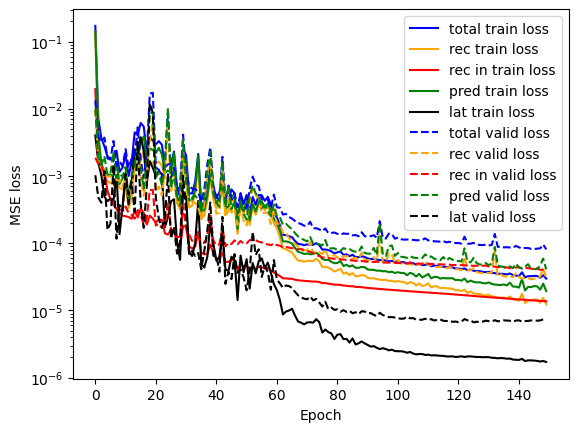

In [52]:
import pickle
import os

# Load history
save_dir = "./tutorial_training_results"
history_path = os.path.join(save_dir, "history.pkl")
with open(history_path, "rb") as f:
    history = pickle.load(f)

# Plot Learning Curves
fig, axs = plt.subplots()
axs.set_yscale('log')
axs.set_xlabel('Epoch')
axs.set_ylabel('MSE loss')
axs.plot(history['avg_epoch_total_loss_train'], color='blue', linestyle='-', label='total train loss')
axs.plot(history['avg_epoch_rec_loss_train'], color='orange', linestyle='-', label='rec train loss')
axs.plot(history['avg_epoch_rec_in_loss_train'], color='red', linestyle='-', label='rec in train loss')
axs.plot(history['avg_epoch_pred_loss_train'], color='green', linestyle='-', label='pred train loss')
axs.plot(history['avg_epoch_lat_loss_train'], color='black', linestyle='-', label='lat train loss')

axs.plot(history['epoch_total_loss_valid'], color='blue', linestyle='--', label='total valid loss')
axs.plot(history['epoch_rec_loss_valid'], color='orange', linestyle='--', label='rec valid loss')
axs.plot(history['epoch_rec_in_loss_valid'], color='red', linestyle='--', label='rec in valid loss')
axs.plot(history['epoch_pred_loss_valid'], color='green', linestyle='--', label='pred valid loss')
axs.plot(history['epoch_lat_loss_valid'], color='black', linestyle='--', label='lat valid loss')
axs.legend()

### Model Inference

Finally, let's use the trained model to predict a sequence from the test set and visualize the results.

In [66]:
# load the model
model.load_state_dict(torch.load('./tutorial_training_results/best_model.pth'))

# Evaluate a test simulation
sim_idx = 30
sim_length = 200
test_sim = processed_data['simulations']['train'][sim_idx]

# get initial conditions and controls
X0 = test_sim.states_scaled[:, :lookback,:]
U = test_sim.controls

# ground truth states
true_states = test_sim.states_scaled[:, lookback:lookback+sim_length, :]

# Inference
model.config.pred_horizon = sim_length # the model was trained for 30 steps, but we can predict longer sequences
model.eval()
with torch.no_grad():
    _, _, pred_latents, pred_states = model(X0, U)
    # Get the true latents
    true_latents = model.encoder(true_states)

# Convert to cpu for plotting
true_states = true_states.squeeze(0).cpu()
pred_states = pred_states.squeeze(0).cpu()
true_latents = true_latents.squeeze(0).cpu()
pred_latents = pred_latents.squeeze(0).cpu()

We visualize first the preduicted dynamics within the latent space:

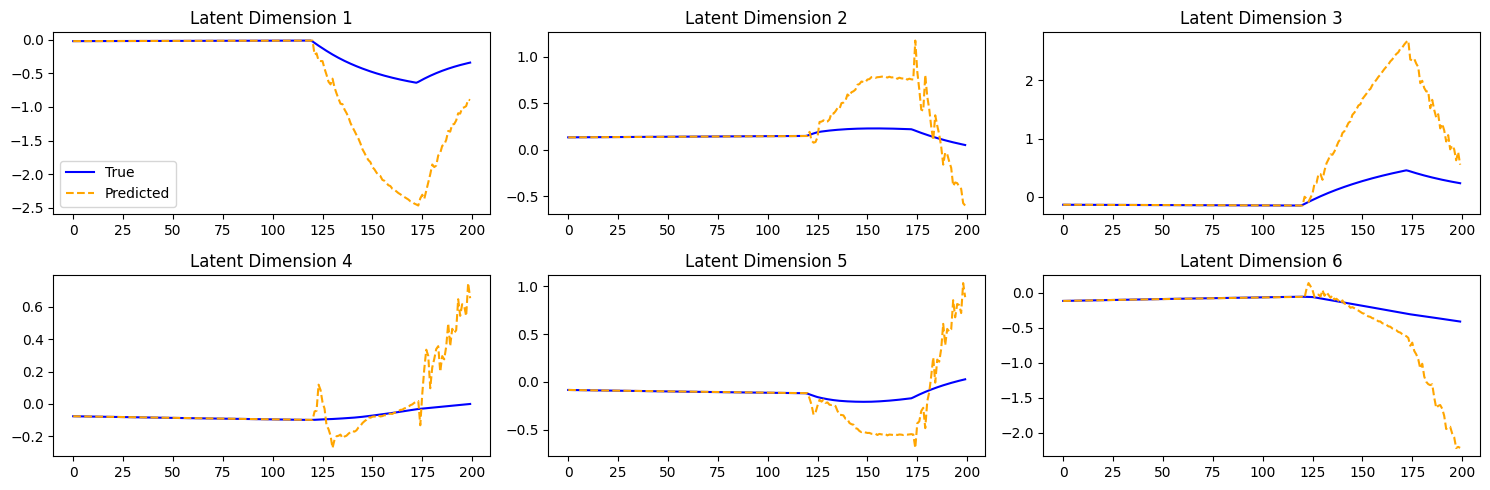

In [67]:
plt.figure(figsize=(15, 5))
for i in range(latent_dim):
    plt.subplot(2, latent_dim//2, i+1)
    plt.plot(true_latents[:, i], label='True', color='blue')
    plt.plot(pred_latents[:, i], label='Predicted', color='orange', linestyle='--')
    plt.title(f'Latent Dimension {i+1}')
    #plt.ylim([0,1])
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()

Second, we visualize the decoded high-dimensional states:

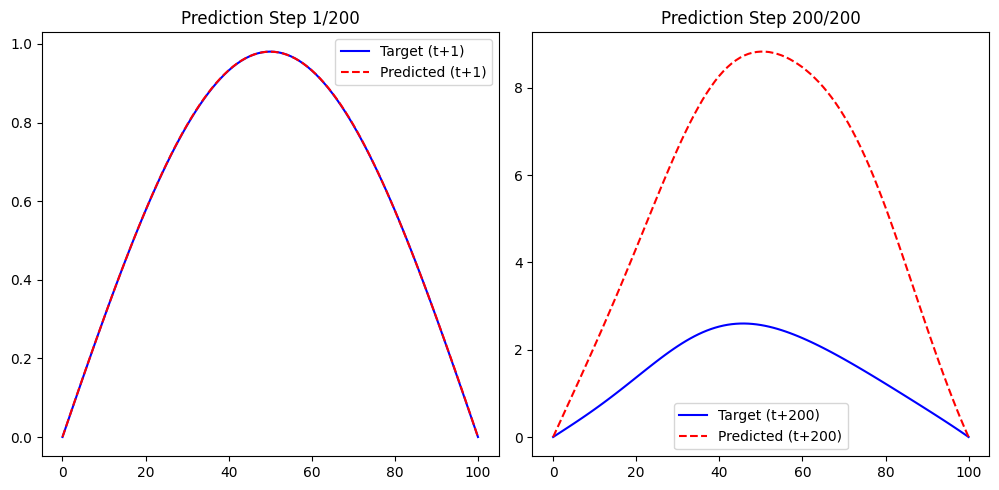

Comparison animation saved to: ./images/1D_simulation_prediction.gif


In [68]:
# Plotting
plt.figure(figsize=(15, 5))

# 2. Future Prediction (First Step)
plt.subplot(1, 3, 1)
plt.plot(true_states[0], 'b-', label='Target (t+1)')
plt.plot(pred_states[0], 'r--', label='Predicted (t+1)')
plt.title(f"Prediction Step 1/{model.config.pred_horizon}")
plt.legend()

# 3. Future Prediction (Last Step)
plt.subplot(1, 3, 2)
plt.plot(true_states[-1], 'b-', label=f'Target (t+{model.config.pred_horizon})')
plt.plot(pred_states[-1], 'r--', label=f'Predicted (t+{model.config.pred_horizon})')
plt.title(f"Prediction Step {model.config.pred_horizon}/{model.config.pred_horizon}")
plt.legend()

plt.tight_layout()
plt.show()

# save the animation
from deepe2erom import animate_compare_1Dsimulations
animate_compare_1Dsimulations(true_states, pred_states, labels=["Ground truth", "Prediction"], save_path="./images/1D_simulation_prediction.gif")